<a href="https://colab.research.google.com/github/Destian0870/PCVK_Ganjil2026/blob/main/Destian_JB5_PCVK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE = '/content/drive/MyDrive/PCVK/Images/' + '244107020203'  # Ganti NIM_KAMU dengan NIM Anda

**Praktikum1**

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

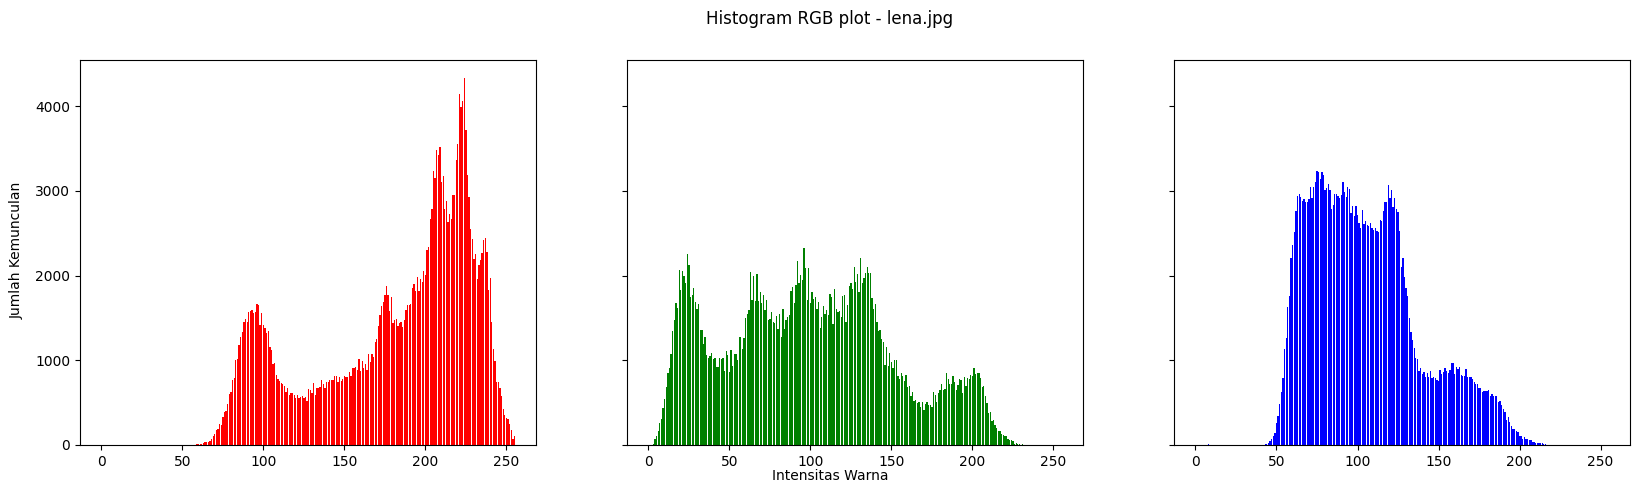

In [ ]:
import urllib.request

# Download otomatis gambar lena.jpg ke Colab
url_lena = "https://raw.githubusercontent.com/gonzae/image-processing-python/master/images/lena.jpg"
try:
    urllib.request.urlretrieve(url_lena, "lena.jpg")
except:
    pass

# Baca gambar dari direktori lokal Colab
img = cv.imread('Lena.png')

if img is None:
    print("Error: File lena.jpg tidak ditemukan!")
else:
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

    height, width, depth = np.shape(img)
    names = np.arange(256)

    red = [0] * 256
    green = [0] * 256
    blue = [0] * 256

    for y in range(0, height):
        for x in range(0, width):
            red[img[y][x][0]] += 1
            green[img[y][x][1]] += 1
            blue[img[y][x][2]] += 1

    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    fig.suptitle('Histogram RGB plot - lena.jpg')
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

    axs[0].bar(names, red, color='red')
    axs[1].bar(names, green, color='green')
    axs[2].bar(names, blue, color='blue')

    plt.show()

**Pertanyaan** **praktikum1**

**Soal1**

In [ ]:
import cv2 as cv
import numpy as np

def compare_histograms(img_path):
    img = cv.imread(img_path)
    if img is None:
        print(f"Error: {img_path} tidak ditemukan!")
        return

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    height, width, _ = img_rgb.shape

    # 1. Manual
    hist_manual = [np.zeros(256, dtype=int) for _ in range(3)]
    for y in range(height):
        for x in range(width):
            for c in range(3):
                hist_manual[c][img_rgb[y, x, c]] += 1

    # 2. NumPy
    hist_numpy = [np.histogram(img_rgb[:, :, c], bins=256, range=[0, 256])[0] for c in range(3)]

    # 3. OpenCV
    hist_cv = [cv.calcHist([img], [c], None, [256], [0, 256]).flatten() for c in range(3)]
    hist_cv = [hist_cv[2], hist_cv[1], hist_cv[0]] # Urutkan BGR ke RGB

    # Pembuktian Selisih Maksimum
    print(f"=== Pembuktian Selisih Maksimum ({img_path}) ===")
    channels = ['Red', 'Green', 'Blue']
    for c in range(3):
        diff_manual_np = np.max(np.abs(hist_manual[c] - hist_numpy[c]))
        diff_np_cv = np.max(np.abs(hist_numpy[c] - hist_cv[c]))
        diff_manual_cv = np.max(np.abs(hist_manual[c] - hist_cv[c]))
        print(f"Kanal {channels[c]}: |Manual - NumPy| = {diff_manual_np}, |NumPy - OpenCV| = {diff_np_cv}, |Manual - OpenCV| = {diff_manual_cv}")

# Jalankan Pembuktian
compare_histograms('Lenna.png')
print("-" * 50)
compare_histograms('KTM3E.jpeg')

=== Pembuktian Selisih Maksimum (Lenna.png) ===
Kanal Red: |Manual - NumPy| = 0, |NumPy - OpenCV| = 0.0, |Manual - OpenCV| = 0.0
Kanal Green: |Manual - NumPy| = 0, |NumPy - OpenCV| = 0.0, |Manual - OpenCV| = 0.0
Kanal Blue: |Manual - NumPy| = 0, |NumPy - OpenCV| = 0.0, |Manual - OpenCV| = 0.0
--------------------------------------------------
=== Pembuktian Selisih Maksimum (KTM3E.jpeg) ===
Kanal Red: |Manual - NumPy| = 0, |NumPy - OpenCV| = 0.0, |Manual - OpenCV| = 0.0
Kanal Green: |Manual - NumPy| = 0, |NumPy - OpenCV| = 0.0, |Manual - OpenCV| = 0.0
Kanal Blue: |Manual - NumPy| = 0, |NumPy - OpenCV| = 0.0, |Manual - OpenCV| = 0.0


**Soal2**

In [ ]:
import cv2 as cv

# Baca file KTM milikmu
img_ktm = cv.imread('KTM3E.jpeg')

if img_ktm is None:
    print("Error: File KTM3E.jpeg tidak ditemukan! Pastikan nama file di Colab sudah benar.")
else:
    # Buat 4 variasi pencahayaan
    ktm1a = cv.convertScaleAbs(img_ktm, alpha=0.4, beta=-60)  # Gelap
    ktm1b = img_ktm.copy()                                    # Normal
    ktm1c = cv.convertScaleAbs(img_ktm, alpha=1.2, beta=40)   # Terang
    ktm1d = cv.convertScaleAbs(img_ktm, alpha=1.4, beta=80)   # Sangat Terang

    # Simpan file
    cv.imwrite('KTM1a.jpeg', ktm1a)
    cv.imwrite('KTM1b.jpeg', ktm1b)
    cv.imwrite('KTM1c.jpeg', ktm1c)
    cv.imwrite('KTM1d.jpeg', ktm1d)

    print("Berhasil membuat file KTM1a.jpeg, KTM1b.jpeg, KTM1c.jpeg, dan KTM1d.jpeg!")

Berhasil membuat file KTM1a.jpeg, KTM1b.jpeg, KTM1c.jpeg, dan KTM1d.jpeg!


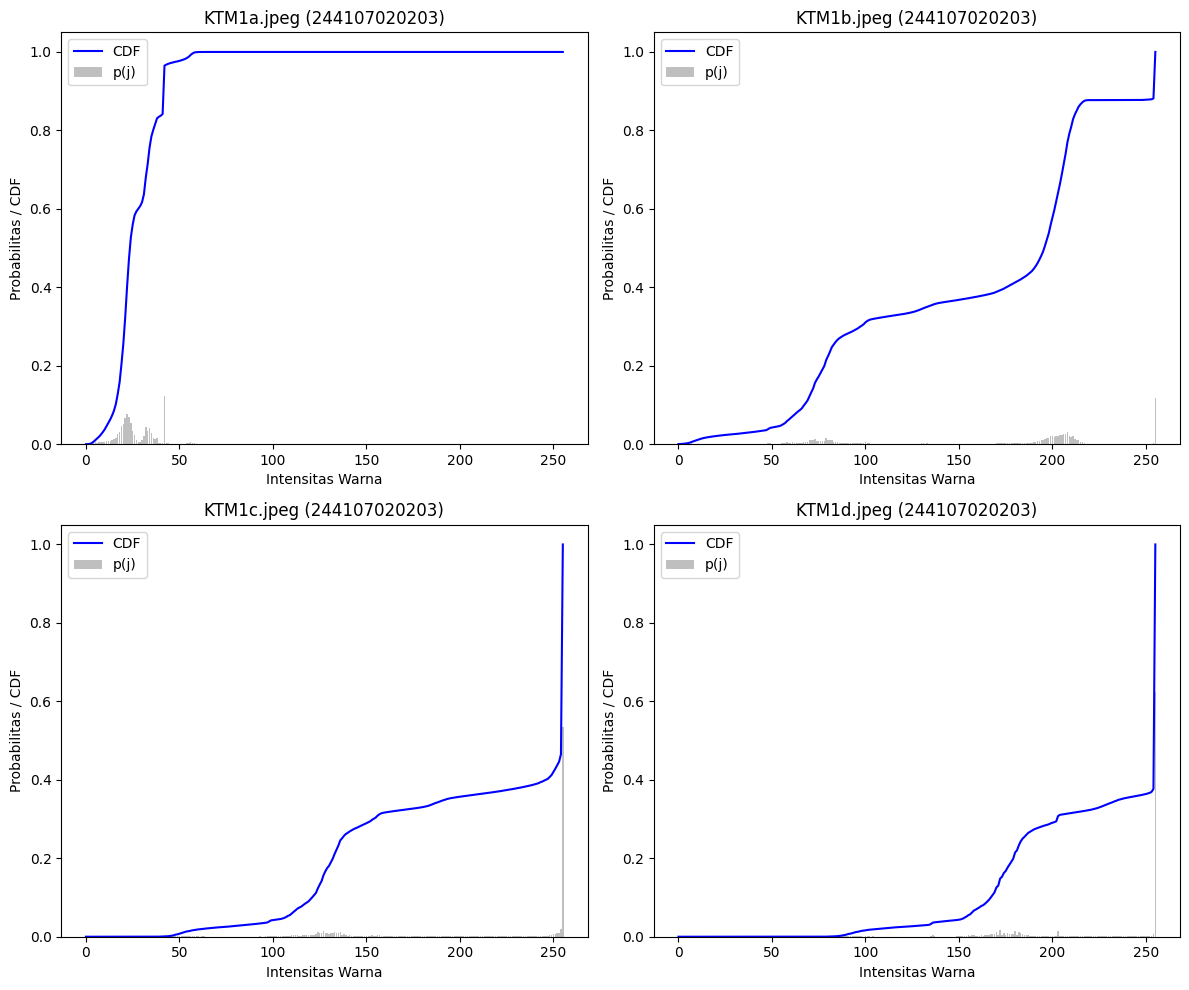

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

ktm_files = ['KTM1a.jpeg', 'KTM1b.jpeg', 'KTM1c.jpeg', 'KTM1d.jpeg']
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for idx, file_name in enumerate(ktm_files):
    img = cv.imread(file_name, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"File {file_name} tidak ditemukan!")
        continue

    # Histogram Ternormalisasi p(j)
    hist, bins = np.histogram(img.flatten(), 256, [0, 256])
    p_j = hist / img.size

    # Kurva CDF
    cdf = p_j.cumsum()

    # Plotting
    ax = axs[idx]
    ax.plot(cdf, color='blue', label='CDF')
    ax.bar(range(256), p_j, color='gray', alpha=0.5, label='p(j)')
    ax.set_title(f'{file_name} (244107020203)')
    ax.set_xlabel('Intensitas Warna')
    ax.set_ylabel('Probabilitas / CDF')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Soal3**

/tmp/ipykernel_7550/1575551184.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax1.hist(img_ktm.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_7550/1575551184.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  ax2.hist(img_ktm.ravel(), param_bins, [0, 256], color='red')


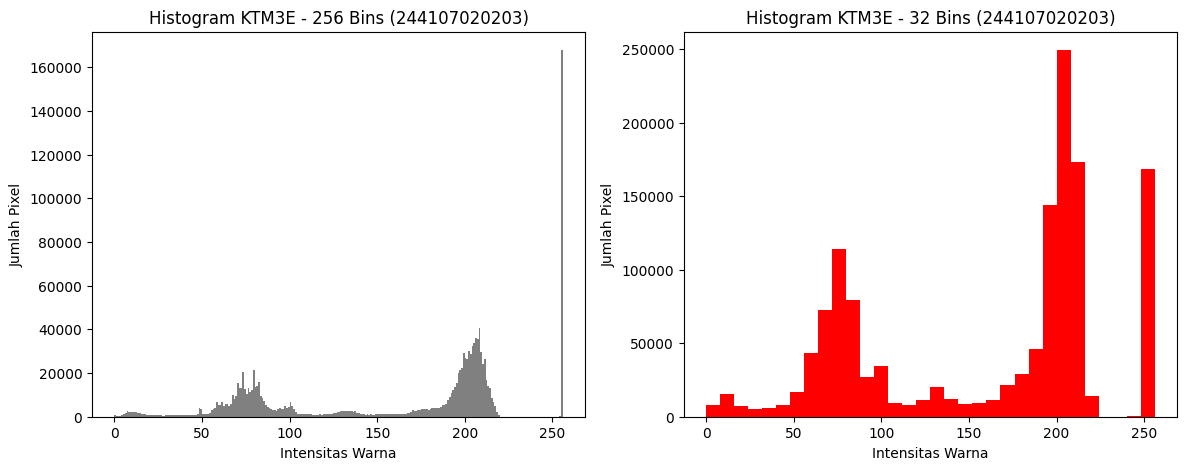

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

# Membaca gambar KTM3E milikmu dalam grayscale
img_ktm = cv.imread('KTM3E.jpeg', cv.IMREAD_GRAYSCALE)

if img_ktm is None:
    print("Error: File KTM3E.jpeg tidak ditemukan di panel file Colab!")
else:
    param_bins = 32  # Jumlah bin yang dikurangi (misal PARAM['bins'] = 32)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram 256 Bins
    ax1.hist(img_ktm.ravel(), 256, [0, 256], color='gray')
    ax1.set_title('Histogram KTM3E - 256 Bins (244107020203)')
    ax1.set_xlabel('Intensitas Warna')
    ax1.set_ylabel('Jumlah Pixel')

    # Histogram 32 Bins
    ax2.hist(img_ktm.ravel(), param_bins, [0, 256], color='red')
    ax2.set_title(f'Histogram KTM3E - {param_bins} Bins (244107020203)')
    ax2.set_xlabel('Intensitas Warna')
    ax2.set_ylabel('Jumlah Pixel')

    plt.show()

**Praktikum2**

In [ ]:
import cv2 as cv

img_lena = cv.imread('Lena.png')
if img_lena is not None:
    # Ubah kontras Lena menjadi low contrast (lc)
    lena_lc = cv.convertScaleAbs(img_lena, alpha=0.35, beta=70)
    cv.imwrite('lena_lc.jpg', lena_lc)
    print("File lena_lc.jpg berhasil dibuat dari Lena.png!")
else:
    print("Error: File Lena.png tidak ditemukan!")

File lena_lc.jpg berhasil dibuat dari Lena.png!


=== HASIL lena_lc.jpg (NIM: 244107020203) ===
Selisih Maksimum (Manual vs cv.equalizeHist) = 0


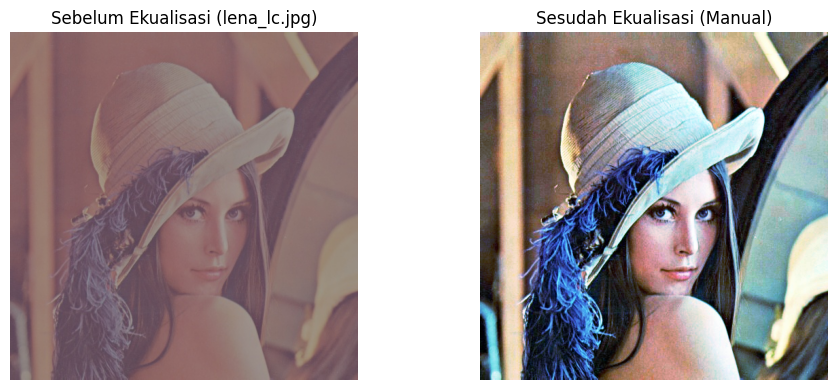

--------------------------------------------------
=== HASIL KTM1a.jpeg (NIM: 244107020203) ===
Selisih Maksimum (Manual vs cv.equalizeHist) = 1


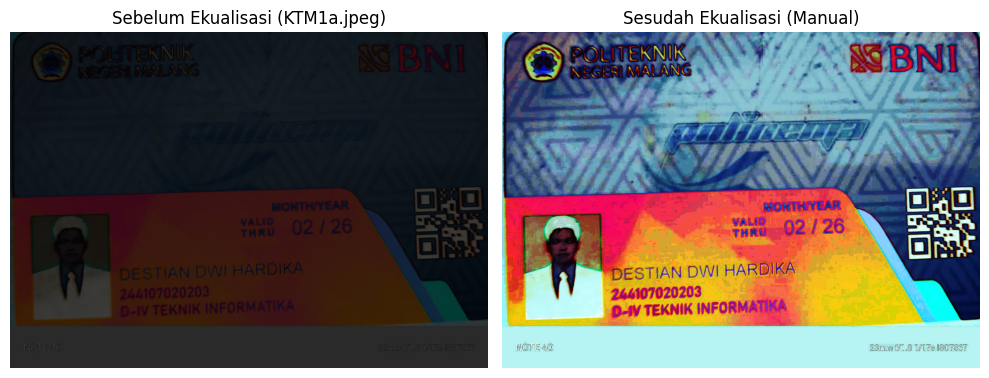

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. BUAT FILE lena_lc.jpg JIKA BELUM ADA
img_lena = cv.imread('lena.jpg')
if img_lena is None:
    img_lena = cv.imread('Lenna.png') # Cek variasi nama file Lenna

if img_lena is not None:
    # Buat versi low-contrast (lena_lc.jpg)
    lena_lc = cv.convertScaleAbs(img_lena, alpha=0.4, beta=60)
    cv.imwrite('lena_lc.jpg', lena_lc)
    print("File lena_lc.jpg berhasil dibuat!")

# 2. FUNGSI EKUALISASI & TAMPILKAN HASIL
def run_equalization_test(img_path):
    img_bgr = cv.imread(img_path)
    if img_bgr is None:
        print(f"Error: {img_path} tidak ditemukan!")
        return

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
    h, w, c = img_rgb.shape
    total_pixels = h * w

    # Implementation Manual
    img_manual_rgb = np.zeros_like(img_rgb)
    for ch in range(3):
        hist, _ = np.histogram(img_rgb[:, :, ch].flatten(), 256, [0, 256])
        cdf = hist.cumsum() / total_pixels
        skala_warna = np.round(cdf * 255).astype(np.uint8)
        img_manual_rgb[:, :, ch] = skala_warna[img_rgb[:, :, ch]]

    # Implementation OpenCV
    b, g, r = cv.split(img_bgr)
    img_cv_rgb = cv.cvtColor(cv.merge([cv.equalizeHist(b), cv.equalizeHist(g), cv.equalizeHist(r)]), cv.COLOR_BGR2RGB)

    # Hitung Selisih Maksimum
    diff_max = np.max(np.abs(img_manual_rgb.astype(int) - img_cv_rgb.astype(int)))
    print(f"=== HASIL {img_path} (NIM: 244107020203) ===")
    print(f"Selisih Maksimum (Manual vs cv.equalizeHist) = {diff_max}")

    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(img_rgb)
    axs[0].set_title(f'Sebelum Ekualisasi ({img_path})')
    axs[0].axis('off')

    axs[1].imshow(img_manual_rgb)
    axs[1].set_title('Sesudah Ekualisasi (Manual)')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

# Jalankan Tahap 1 & 2
run_equalization_test('lena_lc.jpg')
print("-" * 50)
run_equalization_test('KTM1a.jpeg')

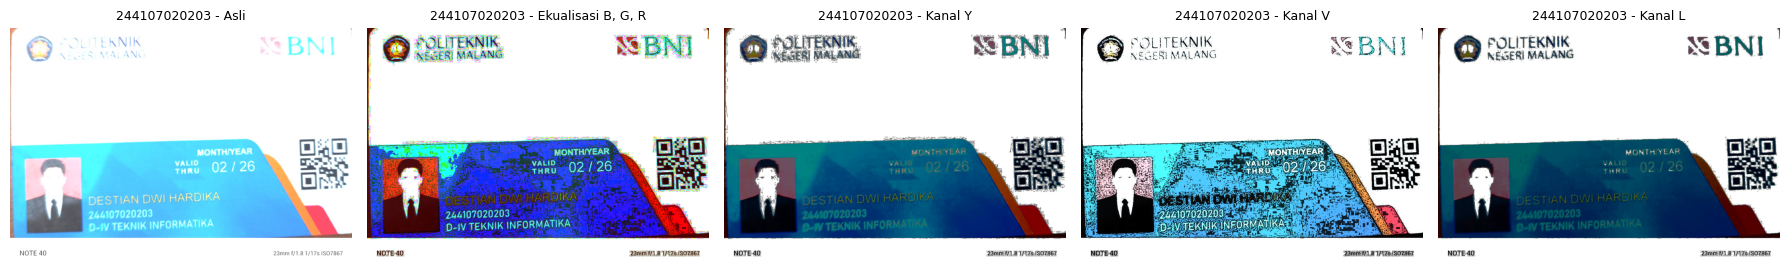

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020203"
berkas = 'KTM1d.jpeg' # Menggunakan citra terang KTM1d milikmu
bgr = cv.imread(berkas)

if bgr is None:
    print(f"Error: File {berkas} tidak ditemukan!")
else:
    # 1. Cara 1: Ekualisasi Kanal B, G, R Terpisah
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # 2. Cara 2: Ruang Warna YCrCb (Hanya Kanal Y)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # 3. Varian HSV (Hanya Kanal V)
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # 4. Varian LAB (Hanya Kanal L)
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # PLOTTING KELIMANYA BERDAMPINGAN
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Fungsi pengukur pergeseran Hue
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
for t, c in zip(judul, citra):
    hue_shift = geser_hue(bgr, c) * 2 if t != 'Asli' else 0.0
    brightness = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    print('%-22s %16.2f %16.1f' % (t, hue_shift, brightness))

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            226.6
Ekualisasi B, G, R                20.86            182.8
Kanal Y                            2.56            177.2
Kanal V                            0.84            201.1
Kanal L                            5.40            174.3


Pertanyaan Analisis **No4**

In [ ]:
import cv2 as cv
import numpy as np

# 1. Inisialisasi CLAHE
PARAM_clip = 2.0
PARAM_tile = 8
clahe = cv.createCLAHE(clipLimit=PARAM_clip, tileGridSize=(PARAM_tile, PARAM_tile))

# 2. Terapkan CLAHE pada Kanal Y (YCrCb)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
y_clahe = clahe.apply(y)
he_y_clahe = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)

# 3. Hitung Pengukuran Kuantitatif
hue_shift_clahe = geser_hue(bgr, he_y_clahe) * 2
brightness_clahe = cv.cvtColor(he_y_clahe, cv.COLOR_BGR2GRAY).mean()

print(f"=== HASIL CLAHE (NIM: 244107020203) ===")
print(f"Pergeseran Hue (CLAHE) : {hue_shift_clahe:.2f}°")
print(f"Rerata Kecerahan (CLAHE): {brightness_clahe:.1f}")

=== HASIL CLAHE (NIM: 244107020203) ===
Pergeseran Hue (CLAHE) : 0.60°
Rerata Kecerahan (CLAHE): 218.9


**Pertanyaan Praktikum2**

**soal1**

=== HASIL SOAL 1c (NIM: 244107020203) ===
Nilai PSNR (Citra Asli vs Ekualisasi Global): 6.20 dB



/tmp/ipykernel_7550/3069577485.py:34: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[0, 1].hist(img_asli.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_7550/3069577485.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_eq.ravel(), 256, [0, 256], color='blue')


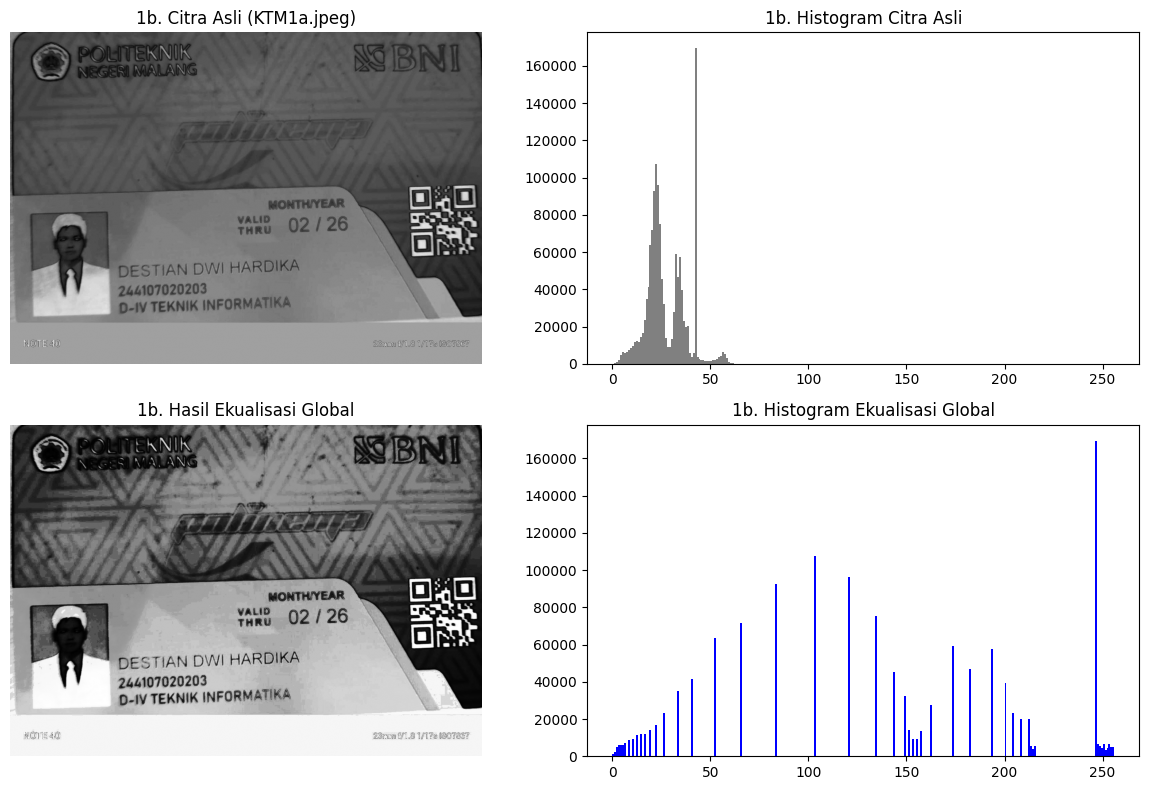

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1a
img_asli = cv.imread('KTM1a.jpeg', cv.IMREAD_GRAYSCALE)

if img_asli is None:
    print("Error: File KTM1a.jpeg tidak ditemukan!")
else:
    # Ekualisasi OpenCV
    img_eq = cv.equalizeHist(img_asli)

    # 1c
    psnr_val = cv.PSNR(img_asli, img_eq)
    print(f"=== HASIL SOAL 1c (NIM: 244107020203) ===")
    print(f"Nilai PSNR (Citra Asli vs Ekualisasi Global): {psnr_val:.2f} dB\n")

    # 1b
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Citra Asli
    axs[0, 0].imshow(img_asli, cmap='gray')
    axs[0, 0].set_title('1b. Citra Asli (KTM1a.jpeg)')
    axs[0, 0].axis('off')

    # Histogram Citra Asli
    axs[0, 1].hist(img_asli.ravel(), 256, [0, 256], color='gray')
    axs[0, 1].set_title('1b. Histogram Citra Asli')

    # Citra Hasil Ekualisasi Global
    axs[1, 0].imshow(img_eq, cmap='gray')
    axs[1, 0].set_title('1b. Hasil Ekualisasi Global')
    axs[1, 0].axis('off')

    # Histogram Hasil Ekualisasi Global
    axs[1, 1].hist(img_eq.ravel(), 256, [0, 256], color='blue')
    axs[1, 1].set_title('1b. Histogram Ekualisasi Global')

    plt.tight_layout()
    plt.show()

**Soal2**

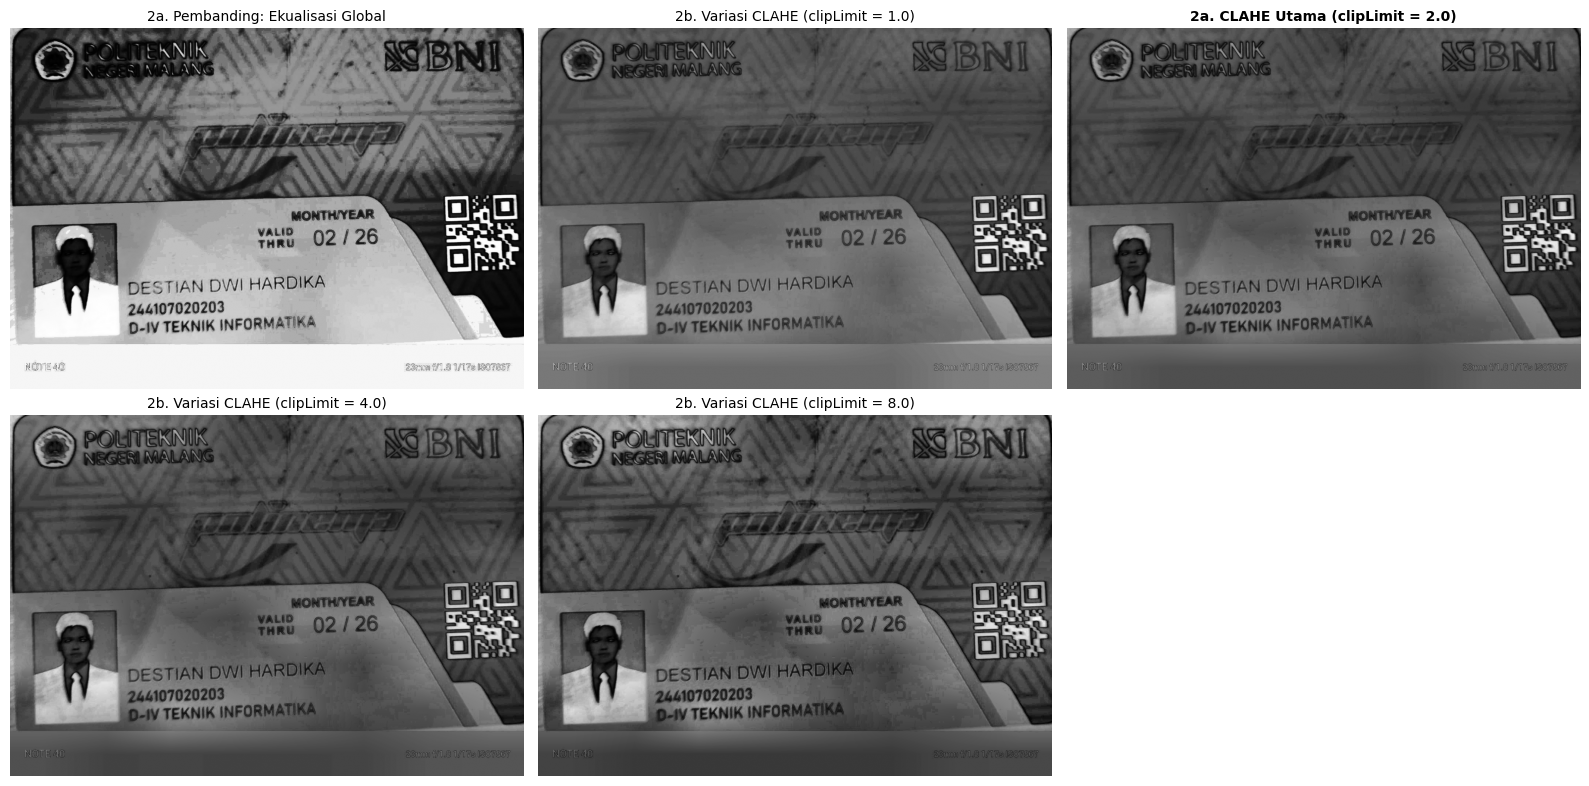

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

if img_asli is not None:
    PARAM_tile = 8

    # 2a.
    clahe_std = cv.createCLAHE(clipLimit=2.0, tileGridSize=(PARAM_tile, PARAM_tile))
    img_clahe_std = clahe_std.apply(img_asli)

    # 2b
    clip_limits = [1.0, 2.0, 4.0, 8.0]

    plt.figure(figsize=(16, 8))

    # Tampilan Pembanding: Ekualisasi Global
    plt.subplot(2, 3, 1)
    plt.imshow(img_eq, cmap='gray')
    plt.title('2a. Pembanding: Ekualisasi Global', fontsize=10)
    plt.axis('off')

    # Visualisasi Variasi clipLimit untuk 2a & 2b
    for idx, clip in enumerate(clip_limits, start=2):
        clahe = cv.createCLAHE(clipLimit=clip, tileGridSize=(PARAM_tile, PARAM_tile))
        img_clahe = clahe.apply(img_asli)

        plt.subplot(2, 3, idx)
        plt.imshow(img_clahe, cmap='gray')
        if clip == 2.0:
            plt.title(f'2a. CLAHE Utama (clipLimit = {clip})', fontsize=10, fontweight='bold')
        else:
            plt.title(f'2b. Variasi CLAHE (clipLimit = {clip})', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

**Tugas**

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Implementasi Floyd-Steinberg berdasarkan Flowchart Modul E-3
def floyd_steinberg_dither(gray_img, L=2):
    img = gray_img.astype(np.float32)
    step = 255.0 / (L - 1)
    H, W = img.shape

    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * (7 / 16)
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * (3 / 16)
            if y + 1 < H:
                img[y + 1, x] += error * (5 / 16)
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * (1 / 16)

    return np.clip(img, 0, 255).astype(np.uint8)

# Fungsi Dithering Berwarna (Menjalankan fungsi 3 kali per kanal B, G, R)
def floyd_steinberg_color(bgr_img, L=2):
    channels = cv.split(bgr_img)
    dithered_channels = [floyd_steinberg_dither(ch, L) for ch in channels]
    return cv.merge(dithered_channels)

**soal1**

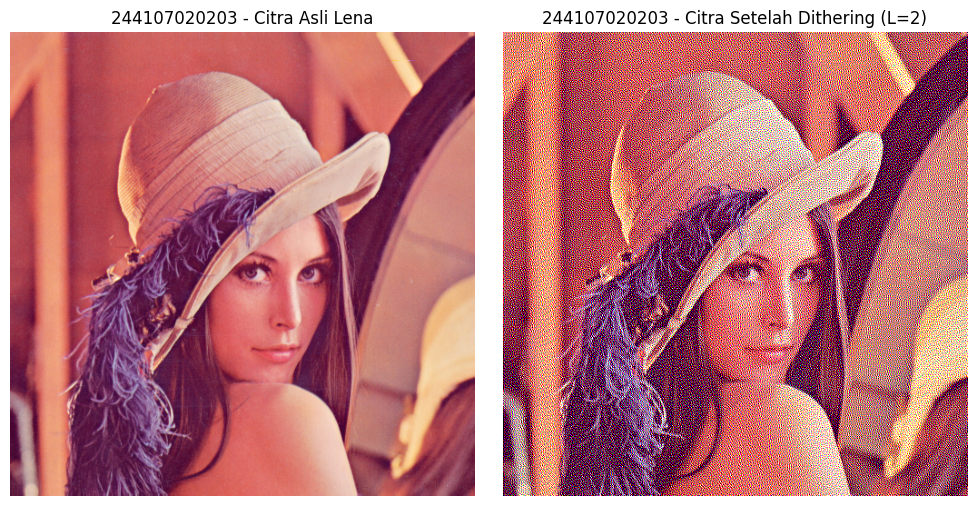

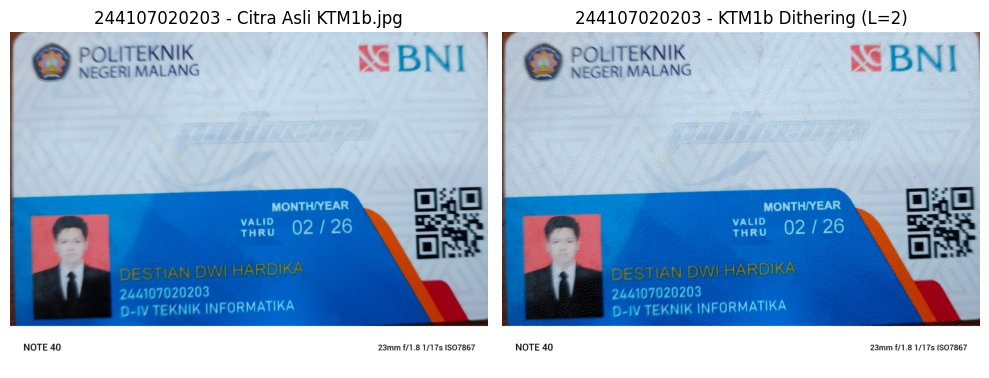

In [ ]:
NIM = "244107020203"
PARAM_L = 2  # Sesuaikan dengan level PARAM['L'] di modulmu

# 1. Tahap 1: lena.jpg
lena_bgr = cv.imread('Lena.png')
if lena_bgr is not None:
    lena_dither = floyd_steinberg_color(lena_bgr, L=PARAM_L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(lena_bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title(f'{NIM} - Citra Asli Lena')
    axs[0].axis('off')

    axs[1].imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
    axs[1].set_title(f'{NIM} - Citra Setelah Dithering (L={PARAM_L})')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: File lena.jpg tidak ditemukan!")

# 1. Tahap 2: KTM1b.jpg
ktm1b_bgr = cv.imread('KTM1b.jpeg')
if ktm1b_bgr is not None:
    ktm1b_dither = floyd_steinberg_color(ktm1b_bgr, L=PARAM_L)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(ktm1b_bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title(f'{NIM} - Citra Asli KTM1b.jpg')
    axs[0].axis('off')

    axs[1].imshow(cv.cvtColor(ktm1b_dither, cv.COLOR_BGR2RGB))
    axs[1].set_title(f'{NIM} - KTM1b Dithering (L={PARAM_L})')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Error: File KTM1b.jpg tidak ditemukan!")

**Soal2**

=== TUGAS 2: CONTOH LENA LOW CONTRAST ===


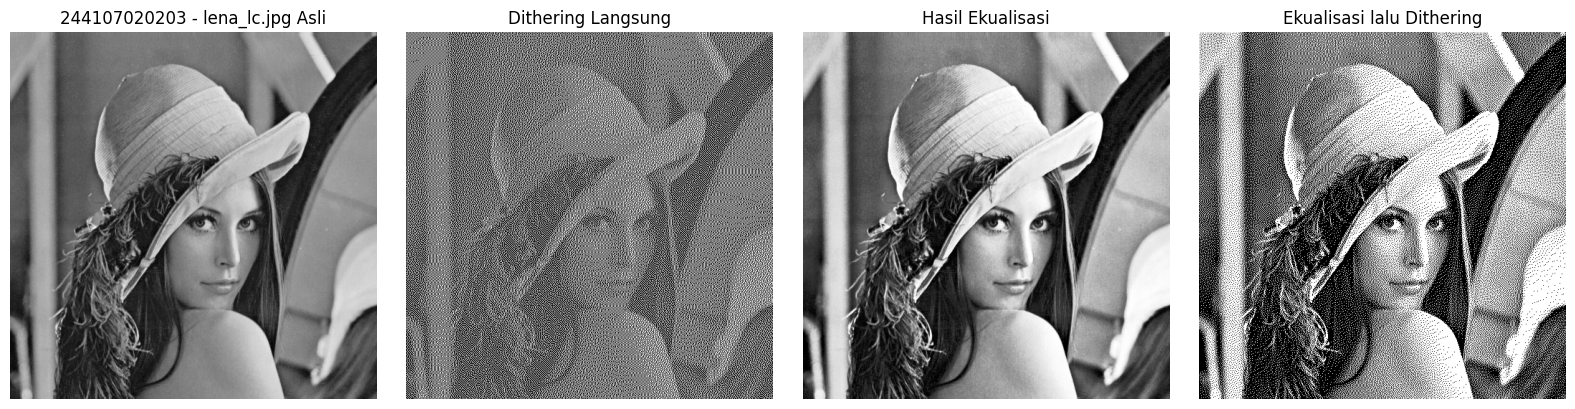


=== TUGAS 2: CITRA KTM1a.jpeg ===


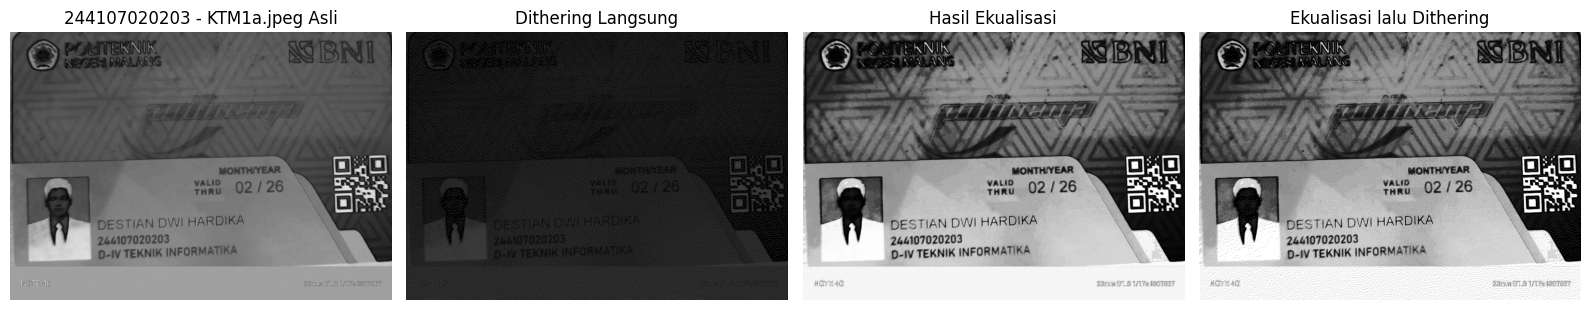

In [ ]:
def process_tugas_2(img_path, title_prefix):
    img_gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Error: {img_path} tidak ditemukan!")
        return

    # 2a. Dithering Langsung tanpa Ekualisasi
    dither_direct = floyd_steinberg_dither(img_gray, L=2)

    # 2b. Ekualisasi Histogram terlebih dahulu
    img_eq = cv.equalizeHist(img_gray)

    # 2c. Dithering setelah Ekualisasi
    dither_after_eq = floyd_steinberg_dither(img_eq, L=2)

    # Plotting 4 Gambar Berdampingan (Sesuai Layout Modul)
    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    axs[0].imshow(img_gray, cmap='gray')
    axs[0].set_title(f'{NIM} - {title_prefix} Asli')
    axs[0].axis('off')

    axs[1].imshow(dither_direct, cmap='gray')
    axs[1].set_title('Dithering Langsung')
    axs[1].axis('off')

    axs[2].imshow(img_eq, cmap='gray')
    axs[2].set_title('Hasil Ekualisasi')
    axs[2].axis('off')

    axs[3].imshow(dither_after_eq, cmap='gray')
    axs[3].set_title('Ekualisasi lalu Dithering')
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

# Eksekusi pada lena_lc.jpg
print("=== TUGAS 2: CONTOH LENA LOW CONTRAST ===")
process_tugas_2('lena_lc.jpg', 'lena_lc.jpg')

# Eksekusi pada KTM1a.jpeg
print("\n=== TUGAS 2: CITRA KTM1a.jpeg ===")
process_tugas_2('KTM1a.jpeg', 'KTM1a.jpeg')